# Assignment Title: 
## Predicting Retail Prices Using Machine Learning for Smart Purchase Decisions


### Step 1: Import Libraries

In this step, we import the required libraries for data manipulation, visualization, and machine learning. These libraries provide tools for building models, evaluating performance, and plotting results.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

### Step 2: Generate Synthetic Dataset

Since real-world pricing data is not easily accessible, we simulate a dataset that mimics retail pricing behavior. This includes variations across stores, products, and time to make the problem realistic.

In [18]:
np.random.seed(42)

stores = ['Store_A', 'Store_B', 'Store_C']
products = ['Milk', 'Bread', 'Eggs']

data = []

for i in range(1000):
    store = np.random.choice(stores)
    product = np.random.choice(products)
    day = np.random.randint(1, 31)

    base_price = {
        'Milk': 2,
        'Bread': 1.5,
        'Eggs': 3
    }[product]

    store_modifier = {
        'Store_A': 0.9,
        'Store_B': 1.0,
        'Store_C': 1.1
    }[store]

    seasonal = 0.1 * np.sin(day)

    price = base_price * store_modifier + seasonal + np.random.normal(0, 0.2)

    data.append([store, product, day, price])

df = pd.DataFrame(data, columns=['store', 'product', 'day', 'price'])

### Step 3: Encode Categorical Variables

Machine learning models require numerical input, so categorical features like store and product names are converted into numerical labels. This allows the models to process and learn from the data.

In [19]:
le_store = LabelEncoder()
le_product = LabelEncoder()

df['store'] = le_store.fit_transform(df['store'])
df['product'] = le_product.fit_transform(df['product'])

### Step 4: Split the Dataset

The dataset is divided into training and testing sets to evaluate model performance. The model learns from training data and is tested on unseen data to measure generalization.

In [20]:
X = df[['store', 'product', 'day']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Step 5: Train Machine Learning Models

We train multiple regression models to predict prices, including Linear Regression, Random Forest, and Gradient Boosting. This allows us to compare simple and advanced approaches.

In [21]:
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100)
xg = xgb.XGBRegressor(n_estimators=100)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xg.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### Step 6: Evaluate Model Performance

We evaluate the models using MAE and RMSE to measure prediction accuracy. These metrics help us understand how close the predicted prices are to actual values.

In [22]:
def evaluate(model, name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

evaluate(lr, "Linear Regression")
evaluate(rf, "Random Forest")
evaluate(xg, "XGBoost")

Linear Regression -> MAE: 0.562, RMSE: 0.623
Random Forest -> MAE: 0.165, RMSE: 0.212
XGBoost -> MAE: 0.172, RMSE: 0.223


### Step 7: Visualize Predictions

A scatter plot is used to compare predicted and actual prices. If the model performs well, the points should lie close to a diagonal line.

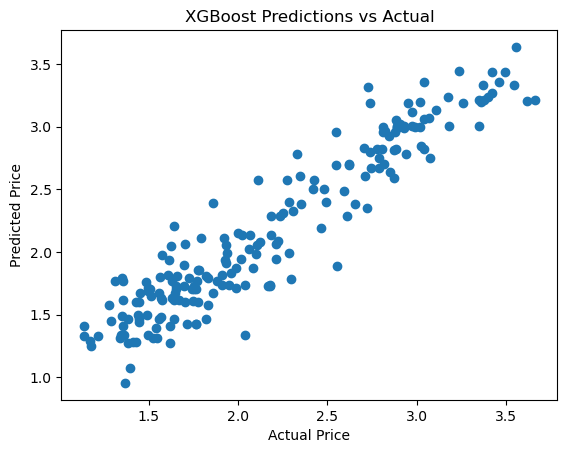

In [23]:
plt.scatter(y_test, xg.predict(X_test))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost Predictions vs Actual")
plt.show()

### Step 8: Compare Prices Across Stores

We predict prices for the same product across different stores. A bar chart is used to visually compare which store offers the lowest price.

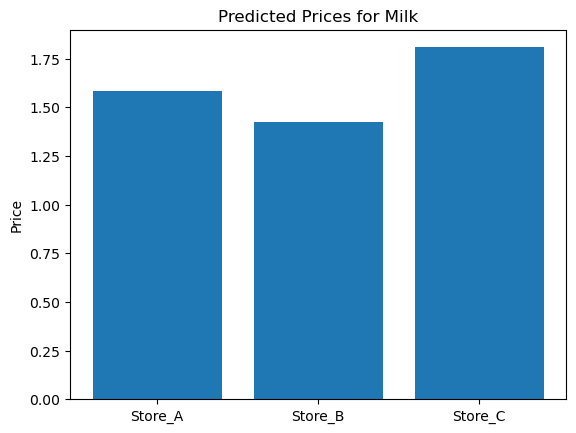

In [24]:
sample = pd.DataFrame({
    'store':[0,1,2],
    'product':[0,0,0],
    'day':[15,15,15]
})

pred_prices = xg.predict(sample)

plt.bar(['Store_A','Store_B','Store_C'], pred_prices)
plt.title("Predicted Prices for Milk")
plt.ylabel("Price")
plt.show()

### Step 9: Analyze Feature Importance

Feature importance shows which inputs have the most influence on price predictions. This helps interpret the model and understand pricing patterns.

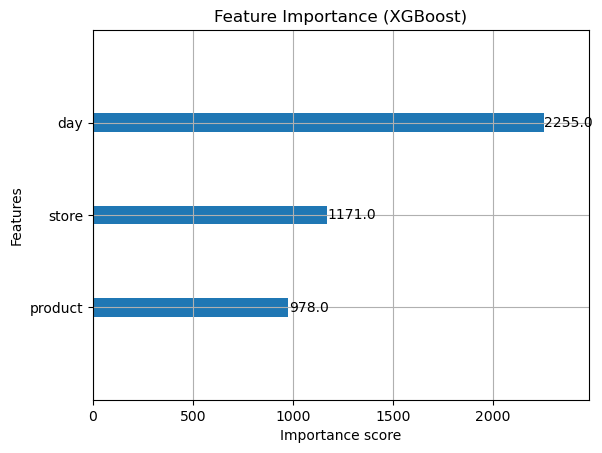

In [25]:
xgb.plot_importance(xg)
plt.title("Feature Importance (XGBoost)")
plt.show()

### Step 10: Recommend the Best Store

Using predicted prices, the system selects the store with the lowest value. This converts the machine learning model into a practical decision-making tool.

In [26]:
best_idx = np.argmin(pred_prices)
best_store = ['Store_A','Store_B','Store_C'][best_idx]

print("Recommended Store:", best_store)

Recommended Store: Store_B


### GitHub Link: https://github.com/pm25aat/price-prediction-ml